In [17]:
# STEP 0 ── INSTALL  (run this cell first, ~3 min)

import subprocess, sys

packages = [
    "langchain==0.3.25",
    "langchain-core==0.3.59",
    "langchain-community==0.3.23",
    "langchain-text-splitters==0.3.8",
    "transformers==4.44.2",
    "accelerate",
    "sentence-transformers",
    "faiss-cpu",
    "pydantic>=2.0,<3.0",
]
for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg], check=True)

print(" All packages installed successfully!")

 All packages installed successfully!


In [18]:

# STEP 1 ── IMPORTS

import warnings
warnings.filterwarnings("ignore")

from langchain_core.prompts          import (PromptTemplate, ChatPromptTemplate,
                                              FewShotPromptTemplate, MessagesPlaceholder)
from langchain_core.output_parsers   import StrOutputParser
from langchain_core.runnables        import RunnablePassthrough, RunnableParallel
from langchain_core.documents        import Document
from langchain_core.runnables.history import RunnableWithMessageHistory

from langchain_community.llms        import HuggingFacePipeline
from langchain_community.llms.fake   import FakeListLLM
from langchain_community.embeddings  import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_community.chat_message_histories import ChatMessageHistory
from langchain_text_splitters        import RecursiveCharacterTextSplitter
from langchain.agents                import Tool

from transformers import pipeline
import torch, matplotlib.pyplot as plt, matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from datetime import date

print(" Imports done |", "GPU " if torch.cuda.is_available() else "CPU mode")

 Imports done | CPU mode


In [19]:
# SECTION 1 ── INTRODUCTION TO LANGCHAIN

"""
WHAT IS LANGCHAIN?
──────────────────
LangChain is an open-source Python framework (Oct 2022, Harrison Chase)
for building LLM-powered applications. It acts as an ORCHESTRATION LAYER
above raw LLM APIs — providing modular, composable, provider-agnostic
building blocks so you don't reinvent the wheel.

WHY DOES IT EXIST?
──────────────────
Raw LLM APIs are stateless HTTP endpoints (text-in → text-out).
Real applications need far more:

  Problem with raw LLMs          │  LangChain Solution
  ─────────────────────────────  │  ──────────────────────────────
  No memory between calls        │  ConversationBufferMemory
  Can't access your private data │  DocumentLoaders + VectorStores
  Can't call external APIs/tools │  Agents + Tools
  Messy unstructured prompts     │  PromptTemplates
  Hard to chain multiple steps   │  LCEL  (pipe operator |)
  50+ different LLM providers    │  One unified interface

CORE PROBLEMS SOLVED:
  1. Orchestration  — coordinate LLM calls, tools, memory in one pipeline
  2. Chaining       — pipe output of one step as input to the next
  3. Retrieval (RAG)— inject your own data without retraining the model
  4. Tool Use       — let LLMs search, calculate, query databases
  5. Standardisation— swap HuggingFace ↔ OpenAI with one line change
"""

print("""

        LangChain — Quick Summary

  Created by : Harrison Chase  (October 2022)
  GitHub     : 70,000+ stars
  Language   : Python  (JS version also exists)
  Purpose    : Orchestration layer for LLM apps
  Key idea   : Modular, composable, provider-agnostic

""")



        LangChain — Quick Summary                   

  Created by : Harrison Chase  (October 2022)        
  GitHub     : 70,000+ stars                        
  Language   : Python  (JS version also exists)     
  Purpose    : Orchestration layer for LLM apps     
  Key idea   : Modular, composable, provider-agnostic




In [4]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 2 ── CORE COMPONENTS  (all 8, with code)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# ── COMPONENT 1: LLMs ────────────────────────────────────────
"""
WHAT  : The language model — text in, text out. LangChain wraps
        any LLM behind a UNIFIED interface (HuggingFace, OpenAI,
        Anthropic, Cohere …). Swapping = changing ONE line.
WHY   : Provider-agnostic code. Prototype free, deploy paid.
TYPES : LLM (string→string)  vs  ChatModel (messages→message)
"""

print("📥 Loading google/flan-t5-base  (~250 MB, local, free)...")
hf_pipe = pipeline(
    "text2text-generation",
    model="google/flan-t5-base",
    max_new_tokens=200,
    temperature=0.7,
    do_sample=True,
    device=-1,            # -1=CPU | 0=GPU
)
llm = HuggingFacePipeline(pipeline=hf_pipe)
print("✅ LLM ready\n")

r = llm.invoke("What is machine learning? Answer in 2 sentences.")
print("[ LLM.invoke ] →", r.strip())

# FakeListLLM — deterministic mock for testing chain structure
fake = FakeListLLM(responses=["LangChain simplifies LLM app development.",
                               "It supports chains, agents, memory and RAG."])
print("[ FakeLLM    ] →", fake.invoke("What is LangChain?"))

📥 Loading google/flan-t5-base  (~250 MB, local, free)...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

/tmp/ipykernel_6048/3604572867.py:23: LangChainDeprecationWarning: The class `HuggingFacePipeline` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFacePipeline``.
  llm = HuggingFacePipeline(pipeline=hf_pipe)


✅ LLM ready

[ LLM.invoke ] → machine learning is the study of how computers work
[ FakeLLM    ] → LangChain simplifies LLM app development.


In [5]:
# ── COMPONENT 2: PROMPT TEMPLATES ────────────────────────────
"""
WHAT  : Parameterised prompt strings — separate structure from data.
WHY   : Hard-coded prompts are brittle. Templates are reusable,
        testable, and serialisable (YAML / JSON).
TYPES : PromptTemplate (string)  |  ChatPromptTemplate (messages)
        FewShotPromptTemplate (examples)
"""

# Basic PromptTemplate
basic_pt = PromptTemplate(
    input_variables=["topic", "level"],
    template="Explain {topic} for a {level} student in 2 sentences."
)
print("[ PromptTemplate ] →")
print("  formatted:", basic_pt.format(topic="recursion", level="high school"))
print("  response :", (basic_pt | llm | StrOutputParser()).invoke(
        {"topic": "recursion", "level": "high school"}).strip())

# FewShot PromptTemplate
examples = [{"word": "happy",  "antonym": "sad"},
            {"word": "tall",   "antonym": "short"}]
few_shot = FewShotPromptTemplate(
    examples=examples,
    example_prompt=PromptTemplate(input_variables=["word","antonym"],
                                  template="Word: {word} | Antonym: {antonym}"),
    prefix="Give the antonym:\n",
    suffix="Word: {word} | Antonym:",
    input_variables=["word"],
)
print("\n[ FewShot ] antonym of 'bright' →",
      llm.invoke(few_shot.format(word="bright")).strip())

[ PromptTemplate ] →
  formatted: Explain recursion for a high school student in 2 sentences.
  response : The equinox occurs once every 1,000 years.

[ FewShot ] antonym of 'bright' → bright


In [6]:
# ── COMPONENT 3: CHAINS (LCEL) ────────────────────────────────
"""
WHAT  : Connects components with the PIPE operator  |
        chain = prompt | llm | output_parser
WHY   : Most LLM tasks are multi-step pipelines. LCEL lets you
        declare them cleanly without nested function calls.
PROPERTIES:
  Lazy       — nothing runs until .invoke() is called
  Streamable — .stream() gives token-by-token output
  Batchable  — .batch([]) runs multiple inputs in parallel
  Composable — any Runnable can be piped into another
"""

parser = StrOutputParser()

# Simple chain
capital_chain = (
    PromptTemplate.from_template("What is the capital of {country}?")
    | llm | parser
)
print("[ Simple chain ] capital of Japan →",
      capital_chain.invoke({"country": "Japan"}).strip())

# Parallel chain — runs both prompts simultaneously
parallel = RunnableParallel(
    pros=PromptTemplate.from_template("List 2 pros of {topic}.") | llm | parser,
    cons=PromptTemplate.from_template("List 2 cons of {topic}.") | llm | parser,
)
out = parallel.invoke({"topic": "remote work"})
print("\n[ Parallel chain ] PROS:", out["pros"].strip())
print("                   CONS:", out["cons"].strip())

[ Simple chain ] capital of Japan → nagasaki

[ Parallel chain ] PROS: Remote workers are better at utilizing computer networks and have a much faster time to work.
                   CONS: Remote work makes you lose productivity.


In [7]:
# ── COMPONENT 4: MEMORY ───────────────────────────────────────
"""
WHAT  : Stateful context across conversation turns.
WHY   : LLMs are stateless — each API call is independent.
        Memory injects past chat into the prompt before each call.
MODERN APPROACH (LangChain 0.3+): RunnableWithMessageHistory
TYPES :
  ConversationBufferMemory  — stores every message verbatim
  ConversationSummaryMemory — summarises old messages
  BufferWindowMemory        — keeps only last K turns
"""

store = {}

def get_history(sid):
    if sid not in store:
        store[sid] = ChatMessageHistory()
    return store[sid]

mem_chain = RunnableWithMessageHistory(
    ChatPromptTemplate.from_messages([
        ("system", "You are a helpful assistant. Be concise."),
        MessagesPlaceholder("history"),
        ("human", "{input}"),
    ]) | llm | parser,
    get_history,
    input_messages_key="input",
    history_messages_key="history",
)

cfg = {"configurable": {"session_id": "blog_demo"}}
turns = [
    "My name is Arjun. I study data science.",
    "What should I learn after Python?",
    "What is my name and what do I study?",   # tests memory recall
]
print("[ Memory — multi-turn conversation ]")
for t in turns:
    r = mem_chain.invoke({"input": t}, config=cfg)
    print(f"  👤 {t}")
    print(f"  🤖 {r.strip()}\n")
print(f"  Messages in memory: {len(store['blog_demo'].messages)}")

[ Memory — multi-turn conversation ]
  👤 My name is Arjun. I study data science.
  🤖 Human: Arjun.

  👤 What should I learn after Python?
  🤖 Data science

  👤 What is my name and what do I study?
  🤖 AI: Arjun.

  Messages in memory: 6


In [8]:
# ── COMPONENT 5 & 6: AGENTS + TOOLS ──────────────────────────
"""
AGENTS
  WHAT : An LLM that acts as a reasoning engine — decides WHICH
         tools to call, WHEN, and HOW to combine their results.
  WHY  : Static chains are fixed (A→B→C always). Agents are
         DYNAMIC — the LLM reasons about the problem at runtime.

  ReAct PATTERN (Reason + Act loop):
    Thought:     I need to count chars in 'LangChain'.
    Action:      WordLength
    Input:       LangChain
    Observation: 9 characters.
    Final Answer: 'LangChain' has 9 characters.

TOOLS
  WHAT : Functions the agent can call (name + description + func).
  WHY  : LLMs can't do maths reliably, access real-time data,
         or call APIs. Tools bridge that gap.
"""

def word_length(w):
    w = w.strip()
    return f"'{w}' has {len(w)} characters."

def calculator(expr):
    try:
        parts = expr.split("+")
        return f"{expr.strip()} = {sum(float(p.strip()) for p in parts)}"
    except:
        return "Format: 'a + b'"

def current_date(_=""):
    return f"Today is {date.today().strftime('%B %d, %Y')}."

def unit_convert(q):
    try:
        p = q.lower().split()
        v, f, t = float(p[0]), p[1], p[3]
        m = {("km","miles"):0.621371,("miles","km"):1.60934,
             ("kg","lbs"):2.20462,("lbs","kg"):0.453592}
        if (f,t)==("celsius","fahrenheit"):
            return f"{v}°C = {round(v*9/5+32,2)}°F"
        return f"{v} {f} = {round(v*m[(f,t)],4)} {t}" if (f,t) in m \
               else f"Unsupported: {f}→{t}"
    except:
        return "Format: '10 km to miles'"

tools = [
    Tool("WordLength",    word_length,   "Count characters in a word. Input: single word."),
    Tool("Calculator",    calculator,    "Add two numbers. Input: 'a + b'."),
    Tool("CurrentDate",   current_date,  "Get today's date. Input: empty string."),
    Tool("UnitConverter", unit_convert,  "Convert units km/miles, kg/lbs. Input: '10 km to miles'."),
]

# ReAct simulation (flan-t5 is too small for autonomous ReAct;
# with GPT-4/Claude this loop runs fully autonomously)
tool_map = {t.name: t.func for t in tools}
tasks = [
    ("WordLength",    "LangChain",    "Characters in 'LangChain'?"),
    ("Calculator",    "128 + 256",    "What is 128+256?"),
    ("UnitConverter", "10 km to miles","Convert 10 km to miles."),
    ("CurrentDate",   "",             "What is today's date?"),
]
print("[ Agent — ReAct tool calls ]\n")
for tool_name, inp, question in tasks:
    obs = tool_map[tool_name](inp)
    print(f"   {question}")
    print(f"     ⚡ Tool: {tool_name}  │  ✅ {obs}\n")

[ Agent — ReAct tool calls ]

  ❓ Characters in 'LangChain'?
     ⚡ Tool: WordLength  │  ✅ 'LangChain' has 9 characters.

  ❓ What is 128+256?
     ⚡ Tool: Calculator  │  ✅ 128 + 256 = 384.0

  ❓ Convert 10 km to miles.
     ⚡ Tool: UnitConverter  │  ✅ 10.0 km = 6.2137 miles

  ❓ What is today's date?
     ⚡ Tool: CurrentDate  │  ✅ Today is April 13, 2026.



In [9]:
# ── COMPONENT 7: DOCUMENT LOADERS ────────────────────────────
"""
WHAT  : Ingests data (PDF, CSV, web, Notion …) into LangChain
        Document objects:  Document(page_content="...", metadata={})
WHY   : The INGESTION stage of every RAG pipeline.
        LLMs can't read your files — loaders bridge that gap.
SPLITTERS:
  RecursiveCharacterTextSplitter — recommended default.
  Splits: paragraphs → sentences → words → characters.
"""

knowledge = """
LangChain was created by Harrison Chase in October 2022.
It supports over 50 LLM providers including OpenAI and HuggingFace.
LCEL uses the pipe operator to compose chains declaratively.
RAG stands for Retrieval-Augmented Generation — the core production pattern.
LangSmith is LangChain's observability and debugging platform.
Agents use ReAct: Reason then Act iteratively to solve tasks.
FAISS enables fast approximate nearest-neighbour vector similarity search.
Embeddings convert text into numerical vectors capturing semantic meaning.
Memory persists conversation context across multiple independent LLM calls.
LangGraph extends LangChain for cyclic multi-agent graph-based workflows.
"""

with open("/tmp/lc_kb.txt", "w") as f:
    f.write(knowledge)

loader = TextLoader("/tmp/lc_kb.txt")
docs   = loader.load()

splitter = RecursiveCharacterTextSplitter(
    chunk_size=200, chunk_overlap=30,
    separators=["\n\n", "\n", " ", ""]
)
chunks = splitter.split_documents(docs)
print(f"[ DocumentLoader ] loaded {len(docs)} doc(s), "
      f"split into {len(chunks)} chunks")
for i, c in enumerate(chunks[:3]):
    print(f"  chunk {i+1}: {c.page_content[:80].strip()}...")


[ DocumentLoader ] loaded 1 doc(s), split into 5 chunks
  chunk 1: LangChain was created by Harrison Chase in October 2022.
It supports over 50 LLM...
  chunk 2: RAG stands for Retrieval-Augmented Generation — the core production pattern.
Lan...
  chunk 3: Agents use ReAct: Reason then Act iteratively to solve tasks.
FAISS enables fast...


In [10]:
# ── COMPONENT 8: VECTOR STORES ────────────────────────────────
"""
WHAT  : Database that stores text as dense vectors (embeddings).
        Query = find semantically SIMILAR text, not keyword match.
WHY   : Powers RAG. Retrieve only the top-k relevant chunks to
        inject into the prompt — no full-document context needed.
FLOW  : Docs → embed → FAISS index
        Query → embed query → cosine similarity → top-k chunks
INTERNAL: all-MiniLM-L6-v2 produces 384-dim vectors.
          FAISS uses approximate nearest-neighbour search.
"""

print("📥 Loading sentence-transformers/all-MiniLM-L6-v2  (~90MB)...")
embed_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2",
    model_kwargs={"device": "cpu"},
    encode_kwargs={"normalize_embeddings": True},
)
print("✅ Embeddings model ready")

# Build FAISS index
kb_docs     = [Document(page_content=s.strip())
               for s in knowledge.strip().split("\n") if s.strip()]
vectorstore = FAISS.from_documents(kb_docs, embed_model)
print(f"   FAISS index: {vectorstore.index.ntotal} vectors, "
      f"{len(embed_model.embed_query('test'))} dimensions\n")

# Similarity search
q    = "What is LangSmith used for?"
hits = vectorstore.similarity_search(q, k=2)
print(f"[ VectorStore similarity search ] query: '{q}'")
for i, h in enumerate(hits, 1):
    print(f"  Result {i}: {h.page_content}")

📥 Loading sentence-transformers/all-MiniLM-L6-v2  (~90MB)...


/tmp/ipykernel_6048/3832039764.py:14: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embed_model = HuggingFaceEmbeddings(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Embeddings model ready
   FAISS index: 10 vectors, 384 dimensions

[ VectorStore similarity search ] query: 'What is LangSmith used for?'
  Result 1: LangSmith is LangChain's observability and debugging platform.
  Result 2: LangChain was created by Harrison Chase in October 2022.


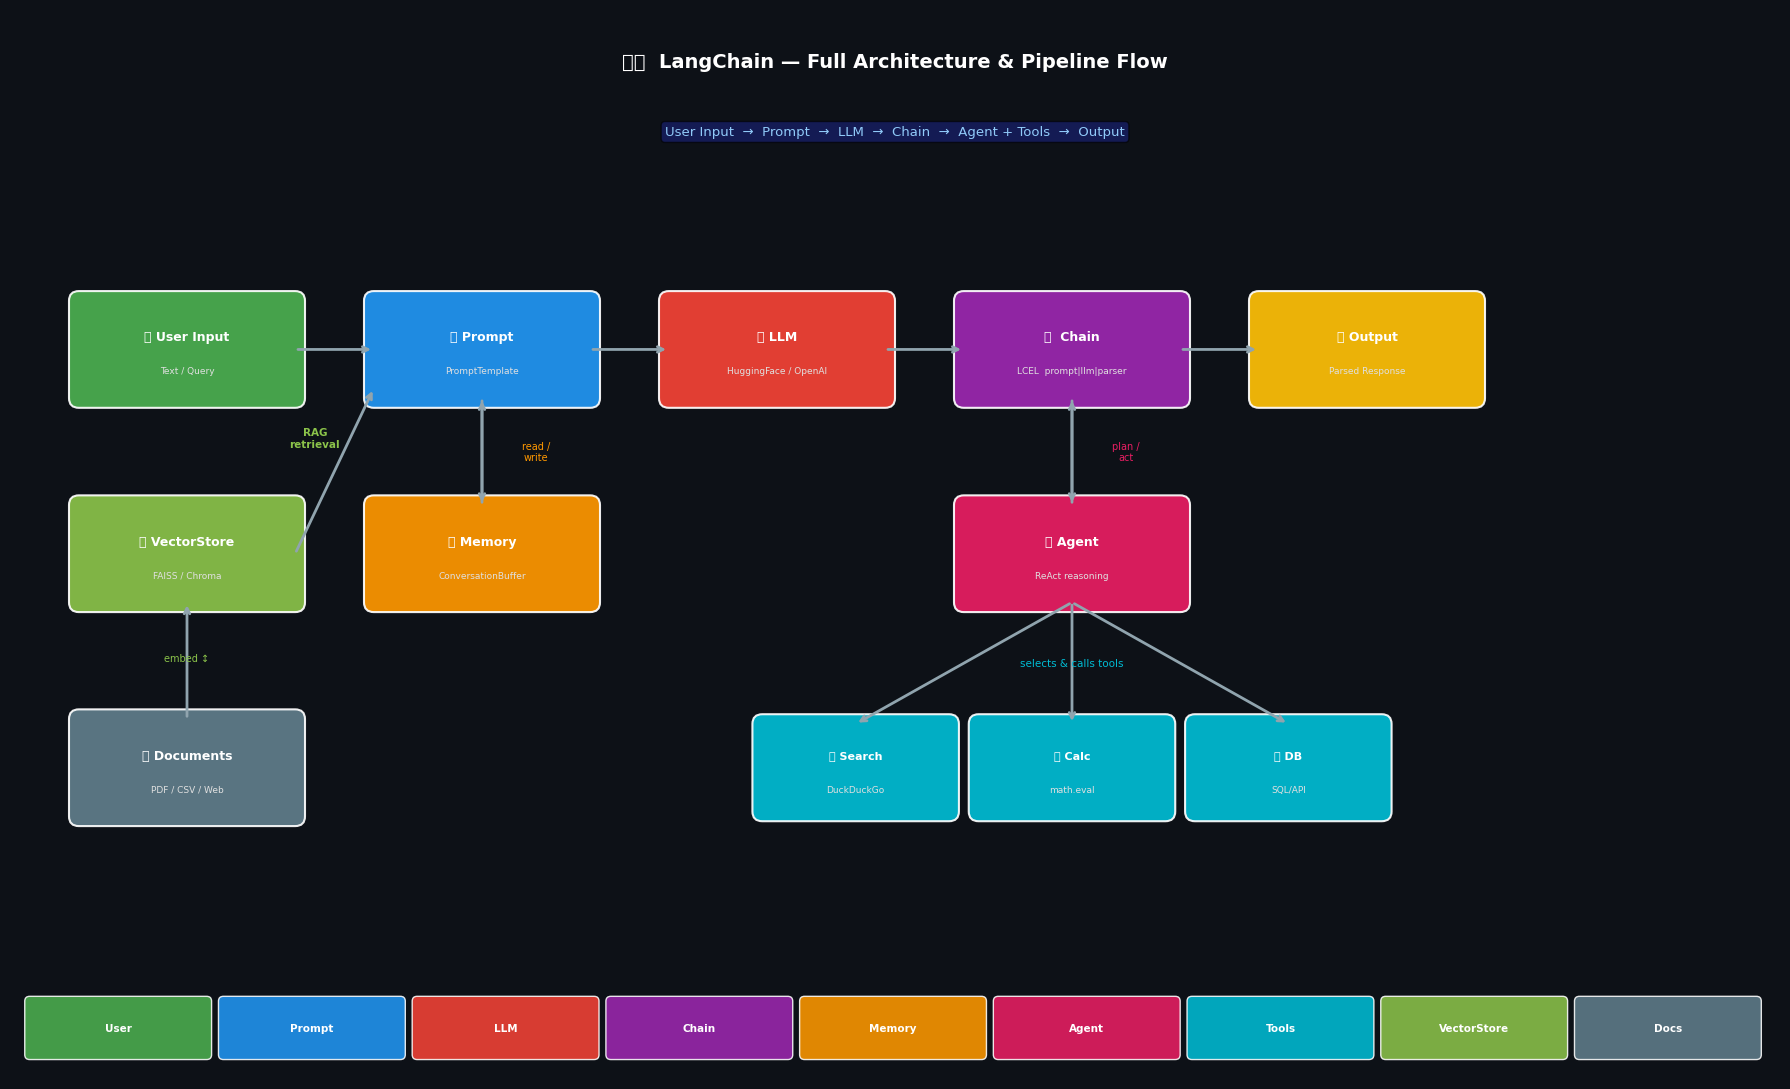

✅ Architecture diagram rendered and saved to /tmp/langchain_arch.png


In [11]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 3 ── ARCHITECTURE DIAGRAM  (mandatory)
# Flow: User → Prompt → LLM → Chain → Agent/Tools → Output
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

fig, ax = plt.subplots(figsize=(18, 11))
ax.set_xlim(0, 18); ax.set_ylim(0, 11); ax.axis("off")
fig.patch.set_facecolor("#0d1117"); ax.set_facecolor("#0d1117")

COL = dict(user="#4CAF50", prompt="#2196F3", llm="#F44336",
           chain="#9C27B0", output="#FFC107", memory="#FF9800",
           agent="#E91E63", tool="#00BCD4", vs="#8BC34A", doc="#607D8B")

def box(x, y, w, h, title, sub, color, fs=9):
    ax.add_patch(FancyBboxPatch((x-w/2, y-h/2), w, h,
        boxstyle="round,pad=0.1", facecolor=color,
        edgecolor="white", linewidth=1.5, alpha=0.92))
    ax.text(x, y+0.13, title, ha="center", va="center",
            fontsize=fs, fontweight="bold", color="white")
    ax.text(x, y-0.22, sub, ha="center", va="center",
            fontsize=6.5, color="#e0e0e0")

def arr(x1, y1, x2, y2, c="#90A4AE"):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="->", color=c, lw=2.0))

# Title
ax.text(9, 10.4, "🦜🔗  LangChain — Full Architecture & Pipeline Flow",
        ha="center", fontsize=14, fontweight="bold", color="white")
ax.text(9, 9.7,
        "User Input  →  Prompt  →  LLM  →  Chain  →  Agent + Tools  →  Output",
        ha="center", fontsize=9.5, color="#90CAF9",
        bbox=dict(boxstyle="round", facecolor="#1a237e", alpha=0.6))

# Main horizontal pipeline  (y = 7.5)
main = [
    (1.8,  7.5, 2.2, 1.0, "👤 User Input",   "Text / Query",            COL["user"]),
    (4.8,  7.5, 2.2, 1.0, "📝 Prompt",       "PromptTemplate",          COL["prompt"]),
    (7.8,  7.5, 2.2, 1.0, "🧠 LLM",          "HuggingFace / OpenAI",    COL["llm"]),
    (10.8, 7.5, 2.2, 1.0, "⛓  Chain",        "LCEL  prompt|llm|parser", COL["chain"]),
    (13.8, 7.5, 2.2, 1.0, "📤 Output",       "Parsed Response",         COL["output"]),
]
for bx,by,bw,bh,lbl,sub,col in main:
    box(bx, by, bw, bh, lbl, sub, col)
for i in range(len(main)-1):
    arr(main[i][0]+main[i][2]/2, 7.5,
        main[i+1][0]-main[i+1][2]/2, 7.5)

# Memory  (below prompt)
box(4.8, 5.4, 2.2, 1.0, "🧠 Memory",  "ConversationBuffer", COL["memory"])
arr(4.8, 5.9,  4.8, 7.0); arr(4.8, 7.0,  4.8, 5.9)
ax.text(5.35, 6.45, "read /\nwrite", fontsize=7, color="#FF9800",
        ha="center", va="center")

# Agent  (below chain)
box(10.8, 5.4, 2.2, 1.0, "🤖 Agent", "ReAct reasoning", COL["agent"])
arr(10.8, 7.0, 10.8, 5.9); arr(10.8, 5.9, 10.8, 7.0)
ax.text(11.35, 6.45, "plan /\nact", fontsize=7, color="#E91E63",
        ha="center", va="center")

# Tools  (below agent)
for tx, tl, ts in [(8.6,"🔍 Search","DuckDuckGo"),
                   (10.8,"🧮 Calc","math.eval"),
                   (13.0,"🗃 DB","SQL/API")]:
    box(tx, 3.2, 1.9, 0.9, tl, ts, COL["tool"], fs=8)
    arr(10.8, 4.9, tx, 3.65)
ax.text(10.8, 4.25, "selects & calls tools",
        ha="center", fontsize=7.5, color="#00BCD4")

# VectorStore + Documents  (left)
box(1.8, 5.4, 2.2, 1.0, "🗄 VectorStore", "FAISS / Chroma",  COL["vs"])
box(1.8, 3.2, 2.2, 1.0, "📂 Documents",   "PDF / CSV / Web", COL["doc"])
arr(1.8, 3.7, 1.8, 4.9)
arr(2.9, 5.4, 3.7, 7.1)
ax.text(1.8, 4.3, "embed ↕", ha="center", fontsize=7, color="#8BC34A")
ax.text(3.1, 6.5, "RAG\nretrieval", ha="center", fontsize=7.5,
        color="#8BC34A", fontweight="bold")

# Legend
legend = [("User",COL["user"]),("Prompt",COL["prompt"]),("LLM",COL["llm"]),
          ("Chain",COL["chain"]),("Memory",COL["memory"]),("Agent",COL["agent"]),
          ("Tools",COL["tool"]),("VectorStore",COL["vs"]),("Docs",COL["doc"])]
for i,(lbl,col) in enumerate(legend):
    ax.add_patch(FancyBboxPatch((0.2+i*1.97, 0.25), 1.8, 0.55,
        boxstyle="round,pad=0.05", facecolor=col, edgecolor="white", alpha=0.88))
    ax.text(0.2+i*1.97+0.9, 0.525, lbl, ha="center", va="center",
            fontsize=7.5, color="white", fontweight="bold")

plt.tight_layout()
plt.savefig("/tmp/langchain_arch.png", dpi=150,
            bbox_inches="tight", facecolor="#0d1117")
plt.show()
print("✅ Architecture diagram rendered and saved to /tmp/langchain_arch.png")

In [12]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 4 ── HANDS-ON CODE EXAMPLES  (6 complete demos)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

sep = lambda t: print(f"\n{'─'*55}\n  {t}\n{'─'*55}")

# ── EXAMPLE 1: Basic LLM — invoke / batch / stream ────────────
sep("EXAMPLE 1 — LLM Invocation Styles")

print("[invoke]  →", llm.invoke(
    "Name 3 programming languages from the 1990s.").strip())

batch_r = llm.batch(["What is 2+2?", "What colour is the sky?"])
for i, r in enumerate(batch_r):
    print(f"[batch Q{i+1}] →", r.strip())

print("[stream]  → ", end="", flush=True)
for tok in llm.stream("List 2 benefits of Python in one sentence."):
    print(tok, end="", flush=True)
print()

# ── EXAMPLE 2: PromptTemplate Chain ──────────────────────────
sep("EXAMPLE 2 — PromptTemplate Chain (Code Review)")

review_chain = (
    PromptTemplate(
        input_variables=["language","code","focus"],
        template=(
            "You are an expert {language} developer.\n"
            "Review this code for {focus}:\n```{language}\n{code}\n```\n"
            "Give feedback in 2 sentences."
        )
    ) | llm | StrOutputParser()
)
print(review_chain.invoke({
    "language": "Python",
    "code":     "def add(a,b):\n    return a+b",
    "focus":    "type hints and docstrings",
}).strip())

# ── EXAMPLE 3: Multi-step Chain ───────────────────────────────
sep("EXAMPLE 3 — Multi-Step Chain  (topic → fact → quiz)")

fact_chain = (
    PromptTemplate.from_template(
        "Give one interesting fact about {animal}."
    ) | llm | StrOutputParser()
)
quiz_chain = (
    PromptTemplate.from_template(
        "Turn this fact into a quiz question: {fact}"
    ) | llm | StrOutputParser()
)

fact = fact_chain.invoke({"animal": "elephants"})
quiz = quiz_chain.invoke({"fact": fact})
print(f"Fact : {fact.strip()}")
print(f"Quiz : {quiz.strip()}")

# ── EXAMPLE 4: Agent with Tools ───────────────────────────────
sep("EXAMPLE 4 — Agent ReAct Loop with Tools")

agent_tasks = [
    ("WordLength",    "LangChain",     "How many characters in 'LangChain'?"),
    ("Calculator",    "128 + 256",     "What is 128 + 256?"),
    ("UnitConverter", "5 km to miles", "Convert 5 km to miles."),
]
for tname, tinput, question in agent_tasks:
    obs = tool_map[tname](tinput)
    print(f"  ❓ {question}")
    print(f"     ⚡ {tname}({tinput!r}) → {obs}\n")

# ── EXAMPLE 5: Memory Chatbot ─────────────────────────────────
sep("EXAMPLE 5 — Multi-Turn Memory Chatbot")

store2 = {}
def hist2(sid):
    if sid not in store2: store2[sid] = ChatMessageHistory()
    return store2[sid]

chatbot = RunnableWithMessageHistory(
    ChatPromptTemplate.from_messages([
        ("system", "You are a concise study assistant."),
        MessagesPlaceholder("history"),
        ("human", "{input}"),
    ]) | llm | StrOutputParser(),
    hist2,
    input_messages_key="input",
    history_messages_key="history",
)
cfg2 = {"configurable": {"session_id": "ex5"}}

for msg in ["I am Priya, studying machine learning.",
            "What should I learn after linear regression?",
            "What is my name and what am I studying?"]:
    r = chatbot.invoke({"input": msg}, config=cfg2)
    print(f"  👤 {msg}")
    print(f"  🤖 {r.strip()}\n")

# ── EXAMPLE 6: Full RAG Pipeline ─────────────────────────────
sep("EXAMPLE 6 — End-to-End RAG Pipeline")

retriever = vectorstore.as_retriever(search_kwargs={"k": 2})
format_docs = lambda docs: "\n\n".join(d.page_content for d in docs)

rag_chain = (
    {
        "context":  retriever | format_docs,
        "question": RunnablePassthrough(),
    }
    | PromptTemplate(
        input_variables=["context","question"],
        template=(
            "Answer ONLY from the context below.\n\n"
            "Context:\n{context}\n\n"
            "Question: {question}\nAnswer:"
        )
    )
    | llm | StrOutputParser()
)

for q in ["Who created LangChain?",
          "What is LangGraph used for?",
          "What does RAG stand for?"]:
    a = rag_chain.invoke(q)
    print(f"  ❓ {q}")
    print(f"     🤖 {a.strip()}\n")


───────────────────────────────────────────────────────
  EXAMPLE 1 — LLM Invocation Styles
───────────────────────────────────────────────────────
[invoke]  → javascript javascript js
[batch Q1] → a simple addition
[batch Q2] → black
[stream]  → Python is a programming language that can be used to code.

───────────────────────────────────────────────────────
  EXAMPLE 2 — PromptTemplate Chain (Code Review)
───────────────────────────────────────────────────────
Python def add(a,b): return a+b

───────────────────────────────────────────────────────
  EXAMPLE 3 — Multi-Step Chain  (topic → fact → quiz)
───────────────────────────────────────────────────────
Fact : An elephant is a large, long-horned animal with wide teddy bear claws.
Quiz : what kind of animal is an elephant?

───────────────────────────────────────────────────────
  EXAMPLE 4 — Agent ReAct Loop with Tools
───────────────────────────────────────────────────────
  ❓ How many characters in 'LangChain'?
     ⚡ WordLengt

In [13]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 5 ── REAL-WORLD USE CASES  (3 + live demo)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("""
USE CASE 1 — Enterprise Document Q&A  (Legal / HR / Finance)
─────────────────────────────────────────────────────────────
  Problem  : A law firm has 10,000+ PDFs. Lawyers need to query
             contracts in plain English for clauses and obligations.
  Solution : PyPDFLoader → TextSplitter → FAISS VectorStore
             → RetrievalQA Chain → LLM answers from retrieved chunks
  Components: DocumentLoader, TextSplitter, Embeddings,
              VectorStore, RAG Chain
  Pseudocode:
    loader   = PyPDFLoader("contract.pdf")
    docs     = loader.load_and_split()
    vdb      = FAISS.from_documents(docs, embed_model)
    qa_chain = rag_chain  # exactly as built in Example 6
    answer   = qa_chain.invoke("What are the termination clauses?")

USE CASE 2 — Intelligent Customer Support Bot  (E-commerce)
─────────────────────────────────────────────────────────────
  Problem  : 5,000 support tickets/day. Need auto-responses that
             can check order status, search FAQs, escalate issues.
  Solution : Memory (session context) + Agent + Tools
             (order DB tool, FAQ search tool, email tool)
  Components: Memory, Agent, Tools, ChatPromptTemplate
  Result   : 70 % ticket deflection, 24/7 instant first response.

USE CASE 3 — Code Review & Documentation Generator  (live demo below)
─────────────────────────────────────────────────────────────
  Problem  : Legacy codebase needs consistent reviews + docstrings.
  Solution : TextLoader → PARALLEL chains
             → review + docstring + complexity in ONE invocation
  Components: Loaders, RunnableParallel, PromptTemplate
""")

# Live demo of Use Case 3
code_sample = """
def binary_search(arr, target):
    left, right = 0, len(arr) - 1
    while left <= right:
        mid = (left + right) // 2
        if arr[mid] == target:   return mid
        elif arr[mid] < target:  left  = mid + 1
        else:                    right = mid - 1
    return -1
"""

docs_gen = RunnableParallel(
    review    = PromptTemplate.from_template(
                    "Review this Python function in 2 sentences:\n{code}"
                ) | llm | StrOutputParser(),
    docstring = PromptTemplate.from_template(
                    "Write a one-line Python docstring for:\n{code}"
                ) | llm | StrOutputParser(),
    complexity= PromptTemplate.from_template(
                    "State the time complexity of this algorithm briefly:\n{code}"
                ) | llm | StrOutputParser(),
)

print("🔍 Auto-analysing binary_search ...\n")
out = docs_gen.invoke({"code": code_sample})
print("📋 Review     :", out["review"].strip())
print("📝 Docstring  :", out["docstring"].strip())
print("⏱  Complexity :", out["complexity"].strip())


USE CASE 1 — Enterprise Document Q&A  (Legal / HR / Finance)
─────────────────────────────────────────────────────────────
  Problem  : A law firm has 10,000+ PDFs. Lawyers need to query
             contracts in plain English for clauses and obligations.
  Solution : PyPDFLoader → TextSplitter → FAISS VectorStore
             → RetrievalQA Chain → LLM answers from retrieved chunks
  Components: DocumentLoader, TextSplitter, Embeddings,
              VectorStore, RAG Chain
  Pseudocode:
    loader   = PyPDFLoader("contract.pdf")
    docs     = loader.load_and_split()
    vdb      = FAISS.from_documents(docs, embed_model)
    qa_chain = rag_chain  # exactly as built in Example 6
    answer   = qa_chain.invoke("What are the termination clauses?")

USE CASE 2 — Intelligent Customer Support Bot  (E-commerce)
─────────────────────────────────────────────────────────────
  Problem  : 5,000 support tickets/day. Need auto-responses that
             can check order status, search FAQs, escala

In [14]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 6 ── ADVANTAGES AND LIMITATIONS
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("""
✅  STRENGTHS
──────────────────────────────────────────────────────────────
  Modularity         Swap any component without rewriting the chain
  Provider-agnostic  One interface for 50+ LLMs
  RAG ecosystem      Best-in-class doc loading, splitting, retrieval
  Rapid prototyping  Working RAG app in under 100 lines of Python
  LCEL               Declarative, streamable, batchable, parallelisable
  Community          70 K+ GitHub stars, 500+ integrations
  LangSmith          Production observability, tracing, evaluation

❌  LIMITATIONS
──────────────────────────────────────────────────────────────
  Latency overhead   Abstraction layers add latency vs raw API calls
  API churn          Breaking changes between v0.1 → v0.2 → v0.3
  Debugging pain     Nested chains are hard to trace without LangSmith
  Cost multiplier    5-step chain = 5× token API cost
  Overkill           A single requests.post() beats LangChain for
                     simple one-shot completions

🚫  WHEN NOT TO USE LANGCHAIN
──────────────────────────────────────────────────────────────
  • Single-turn stateless queries → just call the raw API
  • Latency-critical paths (<100 ms) → raw API is faster
  • Simple chatbots that only need messages.append()
  • Teams still learning raw LLM APIs (understand the base first)

  RULE OF THUMB:
  If your app needs 2+ of (memory, tools, retrieval, multi-LLM
  routing) → LangChain is worth it. Otherwise, keep it simple.
""")


✅  STRENGTHS
──────────────────────────────────────────────────────────────
  Modularity         Swap any component without rewriting the chain
  Provider-agnostic  One interface for 50+ LLMs
  RAG ecosystem      Best-in-class doc loading, splitting, retrieval
  Rapid prototyping  Working RAG app in under 100 lines of Python
  LCEL               Declarative, streamable, batchable, parallelisable
  Community          70 K+ GitHub stars, 500+ integrations
  LangSmith          Production observability, tracing, evaluation

❌  LIMITATIONS
──────────────────────────────────────────────────────────────
  Latency overhead   Abstraction layers add latency vs raw API calls
  API churn          Breaking changes between v0.1 → v0.2 → v0.3
  Debugging pain     Nested chains are hard to trace without LangSmith
  Cost multiplier    5-step chain = 5× token API cost
  Overkill           A single requests.post() beats LangChain for
                     simple one-shot completions

🚫  WHEN NOT TO USE L

In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# SECTION 7 ── CONCLUSION, KEY TAKEAWAYS & FUTURE SCOPE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print("""
🎯  KEY TAKEAWAYS
──────────────────────────────────────────────────────────────
  ✅  LangChain = orchestration layer for LLM applications
  ✅  LCEL pipe (|) is the modern way to compose any pipeline
  ✅  RAG = Loader + Splitter + Embeddings + VectorStore + LLM
  ✅  Agents = LLMs that reason about WHICH tools to call
  ✅  Memory = inject past chat into each prompt automatically
  ✅  All of this runs FREE with local HuggingFace models

🔮  FUTURE SCOPE
──────────────────────────────────────────────────────────────
  LangGraph        Cyclic, stateful, multi-agent graph workflows
                   Agents that loop, backtrack, and coordinate
  Multi-Agent      Researcher + Writer + Critic agents in one task
  Structured Output .with_structured_output() → typed JSON/Pydantic
  Semantic Caching  Cache by MEANING → 80 % latency + cost savings
  Multimodal        Chains that reason over images + text together
""")

# ── Component Quick Reference Table ──────────────────────────
print("─" * 70)
print(f"  {'Component':<18} {'Modern Class':<28} {'Purpose'}")
print("─" * 70)
rows = [
    ("LLM / ChatModel",    "HuggingFacePipeline",         "Text generation"),
    ("PromptTemplate",     "PromptTemplate / ChatPrompt",  "Structured input"),
    ("Chain (LCEL)",       "prompt | llm | parser",        "Composable pipeline"),
    ("Memory",             "RunnableWithMessageHistory",   "Conversation state"),
    ("Agent",              "ReAct loop + tool_map",        "Dynamic tool use"),
    ("Tool",               "Tool(name, func, desc)",       "External capability"),
    ("DocumentLoader",     "TextLoader / PyPDFLoader",     "Data ingestion"),
    ("VectorStore",        "FAISS.from_documents()",       "Semantic search"),
]
for comp, cls, purpose in rows:
    print(f"  {comp:<18} {cls:<28} {purpose}")
print("─" * 70)




🎯  KEY TAKEAWAYS
──────────────────────────────────────────────────────────────
  ✅  LangChain = orchestration layer for LLM applications
  ✅  LCEL pipe (|) is the modern way to compose any pipeline
  ✅  RAG = Loader + Splitter + Embeddings + VectorStore + LLM
  ✅  Agents = LLMs that reason about WHICH tools to call
  ✅  Memory = inject past chat into each prompt automatically
  ✅  All of this runs FREE with local HuggingFace models

🔮  FUTURE SCOPE
──────────────────────────────────────────────────────────────
  LangGraph        Cyclic, stateful, multi-agent graph workflows
                   Agents that loop, backtrack, and coordinate
  Multi-Agent      Researcher + Writer + Critic agents in one task
  Structured Output .with_structured_output() → typed JSON/Pydantic
  Semantic Caching  Cache by MEANING → 80 % latency + cost savings
  Multimodal        Chains that reason over images + text together

──────────────────────────────────────────────────────────────────────
  Component  